# LIBRARY

In [2]:
%pip install scikit-plot -q
%pip install scipy -q

Note: you may need to restart the kernel to use updated packages.
^C
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt

In [4]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error, 
    r2_score
)

# IMPORT CONTROL DATA SET 

In [5]:
file_path = "../4.DATA CLEANING/CMI_V2_CONTROL.csv"
df=pd.read_csv(file_path)
df

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,...,BIA-BIA_TBW,PCIAT-PCIAT_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,PCIAT-PCIAT_Total_CAL,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,1,9,0,NaN,14.035590,48.00,46.0,70.0,NaN,3.0,...,27.055200,0.0,64.0,0.0,0.0,0.0,90.666667,8.0,NaN,11.0
1,3,9,0,71.0,18.292347,56.00,81.6,97.0,6.0,7.0,...,45.996600,44.0,45.0,0.0,1.0,44.0,79.000000,23.0,NaN,7.0
2,5,13,1,50.0,22.279952,59.50,112.2,73.0,5.0,8.0,...,63.126500,34.0,56.0,0.0,1.0,34.0,74.000000,18.0,17.200,10.5
3,6,10,0,NaN,19.660760,55.00,84.6,83.0,NaN,11.0,...,47.221100,20.0,40.0,3.0,0.0,20.0,136.333333,11.0,NaN,11.0
4,7,10,1,65.0,16.861286,59.25,84.2,90.0,5.0,4.0,...,50.476700,NaN,55.0,2.0,0.0,0.0,86.000000,0.0,11.850,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2131,8371,6,0,65.5,15.496182,46.84,64.7,83.5,6.0,NaN,...,32.771756,NaN,NaN,1.0,0.0,0.0,76.000000,0.0,15.025,7.5
2132,8406,10,1,61.5,17.057230,58.32,75.1,82.5,4.0,7.0,...,43.230003,NaN,46.0,0.0,0.0,0.0,111.666667,NaN,NaN,3.0
2133,8426,7,0,77.0,18.020412,64.24,72.4,87.5,NaN,9.0,...,40.690369,NaN,NaN,0.0,0.0,0.0,80.500000,NaN,NaN,8.5
2134,8440,10,1,59.5,17.322879,55.10,72.0,75.5,4.5,7.0,...,41.114615,NaN,NaN,2.0,0.0,0.0,86.166667,11.5,NaN,8.5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2136 entries, 0 to 2135
Data columns (total 29 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      2136 non-null   int64  
 1   Basic_Demos-Age                         2136 non-null   int64  
 2   Basic_Demos-Sex                         2136 non-null   int64  
 3   CGAS-CGAS_Score                         1912 non-null   float64
 4   Physical-BMI                            2136 non-null   float64
 5   Physical-Height                         2136 non-null   float64
 6   Physical-Weight                         2136 non-null   float64
 7   Physical-HeartRate                      2113 non-null   float64
 8   Fitness_Endurance-Max_Stage             1402 non-null   float64
 9   FGC-FGC_TL                              1953 non-null   float64
 10  BIA-BIA_Activity_Level_num              2087 non-null   floa

# Data Cleaning

## null values

In [7]:
df.isnull().sum()

id                                          0
Basic_Demos-Age                             0
Basic_Demos-Sex                             0
CGAS-CGAS_Score                           224
Physical-BMI                                0
Physical-Height                             0
Physical-Weight                             0
Physical-HeartRate                         23
Fitness_Endurance-Max_Stage               734
FGC-FGC_TL                                183
BIA-BIA_Activity_Level_num                 49
BIA-BIA_BMI                                42
BIA-BIA_BMC                                 0
BIA-BIA_DEE                                34
BIA-BIA_FFMI                                0
BIA-BIA_FMI                                 0
BIA-BIA_Fat                                 0
BIA-BIA_Frame_num                          52
BIA-BIA_SMM                                 0
BIA-BIA_TBW                                 0
PCIAT-PCIAT_Total                         407
SDS-SDS_Total_T                   

In [8]:
null_counts = df.isnull().sum()
cols_with_nulls = null_counts[null_counts > 0].index.tolist()
print(f"Columns with nulls: {cols_with_nulls}")

Columns with nulls: ['CGAS-CGAS_Score', 'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_DEE', 'BIA-BIA_Frame_num', 'PCIAT-PCIAT_Total', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL']


In [9]:
for col in cols_with_nulls:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('Unknown')
    else:
        df[col] = df[col].fillna(0)

In [10]:
df.isnull().sum()

id                                        0
Basic_Demos-Age                           0
Basic_Demos-Sex                           0
CGAS-CGAS_Score                           0
Physical-BMI                              0
Physical-Height                           0
Physical-Weight                           0
Physical-HeartRate                        0
Fitness_Endurance-Max_Stage               0
FGC-FGC_TL                                0
BIA-BIA_Activity_Level_num                0
BIA-BIA_BMI                               0
BIA-BIA_BMC                               0
BIA-BIA_DEE                               0
BIA-BIA_FFMI                              0
BIA-BIA_FMI                               0
BIA-BIA_Fat                               0
BIA-BIA_Frame_num                         0
BIA-BIA_SMM                               0
BIA-BIA_TBW                               0
PCIAT-PCIAT_Total                         0
SDS-SDS_Total_T                           0
PreInt_EduHx-computerinternet_ho

## Removing useless variables

In [11]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)

In [127]:
df.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,BIA-BIA_Activity_Level_num,...,BIA-BIA_TBW,PCIAT-PCIAT_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,PCIAT-PCIAT_Total_CAL,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,9,0,0.0,14.035590,48.00,46.0,70.0,0.0,3.0,2.0,...,27.0552,0.0,64.0,0.0,0.0,0.0,90.666667,8.0,0.00,11.0
1,9,0,71.0,18.292347,56.00,81.6,97.0,6.0,7.0,3.0,...,45.9966,44.0,45.0,0.0,1.0,44.0,79.000000,23.0,0.00,7.0
2,13,1,50.0,22.279952,59.50,112.2,73.0,5.0,8.0,2.0,...,63.1265,34.0,56.0,0.0,1.0,34.0,74.000000,18.0,17.20,10.5
3,10,0,0.0,19.660760,55.00,84.6,83.0,0.0,11.0,2.0,...,47.2211,20.0,40.0,3.0,0.0,20.0,136.333333,11.0,0.00,11.0
4,10,1,65.0,16.861286,59.25,84.2,90.0,5.0,4.0,3.0,...,50.4767,0.0,55.0,2.0,0.0,0.0,86.000000,0.0,11.85,0.0


In [12]:
df.columns

Index(['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-HeartRate',
       'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_BMC',
       'BIA-BIA_DEE', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'PCIAT-PCIAT_Total',
       'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'sii',
       'PCIAT-PCIAT_Total_CAL', 'Physical-MAP_CAL', 'FGC-FGC_CORE_CAL',
       'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2136 entries, 0 to 2135
Data columns (total 28 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Basic_Demos-Age                         2136 non-null   int64  
 1   Basic_Demos-Sex                         2136 non-null   int64  
 2   CGAS-CGAS_Score                         2136 non-null   float64
 3   Physical-BMI                            2136 non-null   float64
 4   Physical-Height                         2136 non-null   float64
 5   Physical-Weight                         2136 non-null   float64
 6   Physical-HeartRate                      2136 non-null   float64
 7   Fitness_Endurance-Max_Stage             2136 non-null   float64
 8   FGC-FGC_TL                              2136 non-null   float64
 9   BIA-BIA_Activity_Level_num              2136 non-null   float64
 10  BIA-BIA_BMI                             2136 non-null   floa

# TARGET VARIABLE Physical-BMI

In [16]:
df_BMI = df[['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-HeartRate',
       'BIA-BIA_Fat',
      ]].copy()

In [ ]:
column2drop = ['BIA-BIA_BMI']
df_BMI.drop(column2drop, axis=1, inplace=True)

## Partitioning

In [19]:
attributes = [col for col in df_BMI.columns if col != 'Physical-BMI']
X = df_BMI[attributes].values
y = np.array(df_BMI['Physical-BMI'])

In [20]:
X

array([[  9.        ,   0.        ,   0.        , ...,  46.        ,
         70.        ,   3.97085   ],
       [  9.        ,   0.        ,  71.        , ...,  81.6       ,
         97.        ,  18.8243    ],
       [ 13.        ,   1.        ,  50.        , ..., 112.2       ,
         73.        ,  67.9715    ],
       ...,
       [  7.        ,   0.        ,  77.        , ...,  72.4       ,
         87.5       ,  13.62671895],
       [ 10.        ,   1.        ,  59.5       , ...,  72.        ,
         75.5       ,  19.34623036],
       [ 16.        ,   1.        ,   0.        , ..., 143.9       ,
          0.        ,  37.61712288]])

In [21]:
y

array([14.03559028, 18.29234694, 22.27995198, ..., 18.02041187,
       17.32287858, 23.56995834])

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [23]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1708, 7) (428, 7) (1708,) (428,)


In [24]:
df_BMI.shape

(2136, 8)

## Randomized Search

In [152]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [25]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_bmi = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_bmi = random_search.best_estimator_

In [26]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 39, 'criterion': 'squared_error'} -2.9442350958543537


In [27]:
dt_reg_bmi = random_search.best_estimator_
dt_reg_bmi.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=39, min_samples_leaf=5, min_samples_split=0.002)

In [28]:
y_pred = dt_reg_bmi.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 1.6734
MAE  : 1.0206
R²   : 0.8577


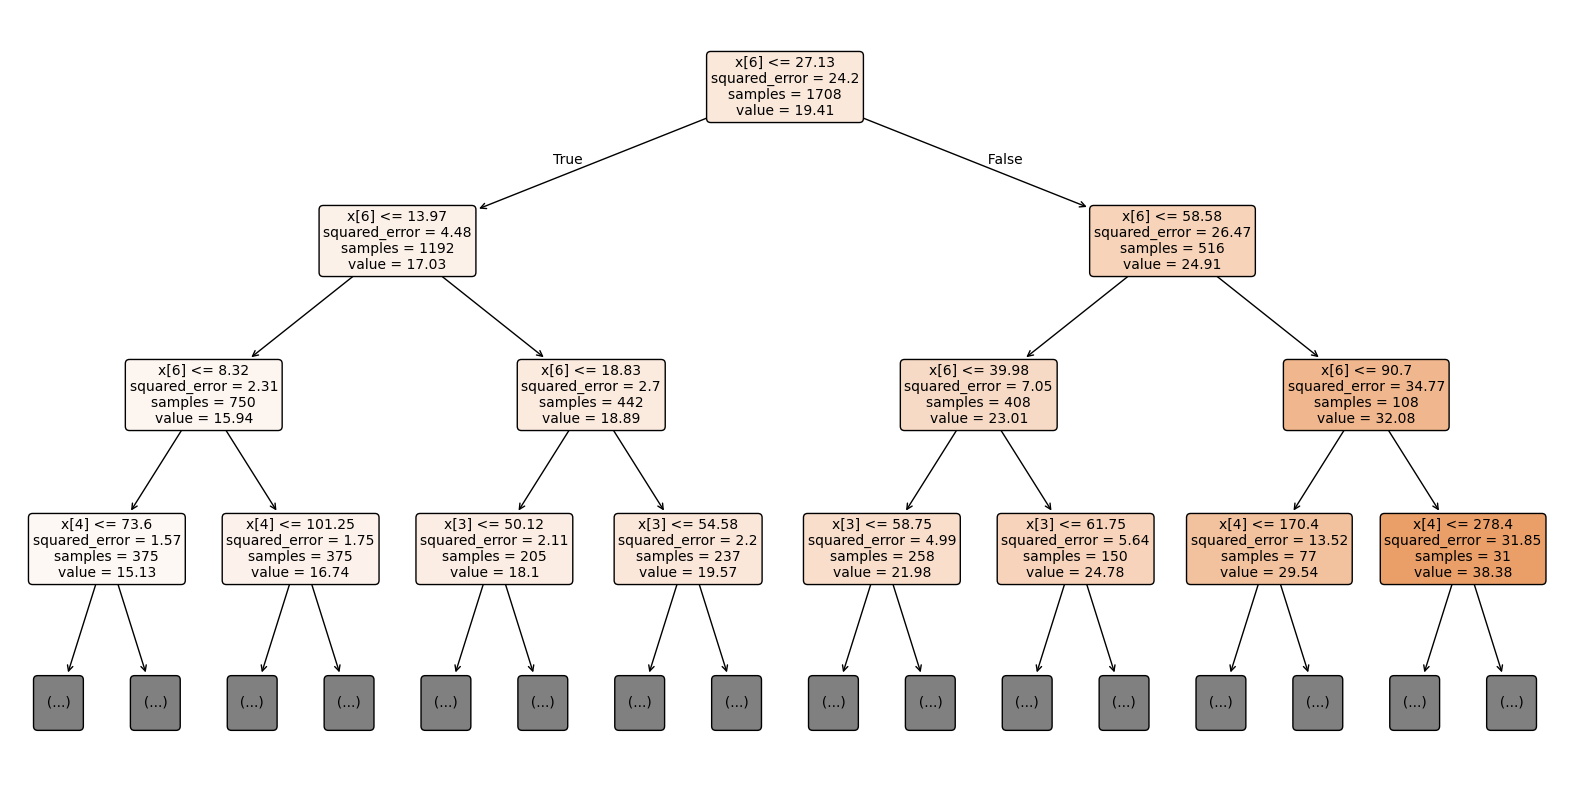

In [29]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_bmi,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 209 | 30.0946 |   18.5179 | 11.5768
 216 | 21.7517 |   32.0945 | 10.3428
 425 | 31.8559 |   22.2853 | 9.5706
 161 | 24.9522 |   15.7169 | 9.2353
 221 | 19.7604 |   26.7647 | 7.0043
  77 | 32.5552 |   26.9499 | 5.6052
 186 | 16.7149 |   22.1382 | 5.4233
 368 | 35.2947 |   30.4544 | 4.8403
 143 | 15.4962 |   20.3161 | 4.8199
 402 | 24.1841 |   19.6211 | 4.5630


C:\Users\paula\AppData\Local\Temp\ipykernel_10760\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


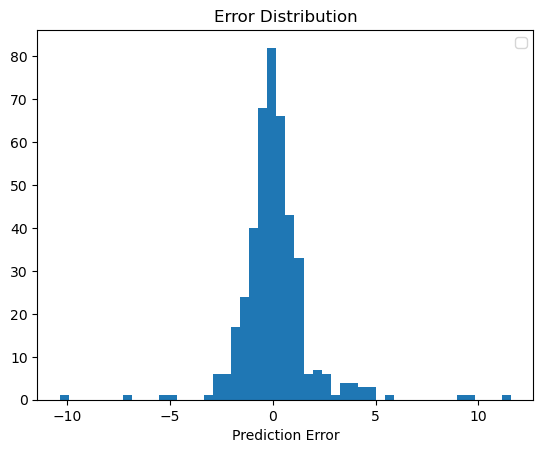

In [30]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [31]:
zipped = zip(attributes, dt_reg_bmi.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_Fat 0.8961214041924485
Physical-Weight 0.050419834788541645
Physical-Height 0.04184103229420756
CGAS-CGAS_Score 0.00529871658807381
Basic_Demos-Age 0.002960456815131935
Physical-HeartRate 0.002670066932209126
Basic_Demos-Sex 0.0006884883893873785


First results with all the values
BIA-BIA_BMI 0.982692500524383
BIA-BIA_FMI 0.012711196383532634
BIA-BIA_SMM 0.004305795435728201
FGC-FGC_GS_CAL 9.932473275050479e-05
Physical-Height 6.61128225083028e-05
FGC-FGC_TL 5.3790738621830106e-05
SDS-SDS_Total_T 4.7246216589660637e-05
Physical-MAP_CAL 2.4033145885833855e-05

# IMPORT DATASET

In [160]:
file_path = "../4.DATA CLEANING/CMI_V2.csv"
df_clean=pd.read_csv(file_path)
df_clean

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,...,BIA-BIA_TBW,PCIAT-PCIAT_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,PCIAT-PCIAT_Total_CAL,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,0,5,0,51.0,16.877316,46.00,50.8,NaN,5.0,6.0,...,32.690900,55.0,NaN,3.0,2.0,55.0,NaN,0.0,NaN,6.5
1,1,9,0,NaN,14.035590,48.00,46.0,70.0,NaN,3.0,...,27.055200,0.0,64.0,0.0,0.0,0.0,90.666667,8.0,NaN,11.0
2,2,10,1,71.0,16.648696,56.50,75.6,94.0,5.0,5.0,...,44.987000,28.0,54.0,2.0,0.0,28.0,82.333333,27.0,12.450,10.0
3,3,9,0,71.0,18.292347,56.00,81.6,97.0,6.0,7.0,...,45.996600,44.0,45.0,0.0,1.0,44.0,79.000000,23.0,NaN,7.0
4,4,18,1,65.0,17.937682,NaN,77.0,NaN,NaN,10.0,...,NaN,NaN,NaN,1.0,0.0,0.0,NaN,12.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455,7,1,NaN,16.130585,46.07,49.0,82.5,2.5,8.0,...,31.583004,NaN,55.0,0.0,0.0,0.0,NaN,6.5,18.075,7.0
8456,8456,10,1,69.5,NaN,56.13,47.8,80.5,5.0,8.0,...,36.475662,NaN,NaN,0.0,1.0,0.0,79.833333,8.5,13.575,5.0
8457,8457,10,1,70.0,40.937571,49.56,47.2,83.5,7.0,NaN,...,35.106855,NaN,NaN,2.0,0.0,0.0,82.166667,21.5,NaN,9.5
8458,8458,15,1,55.5,NaN,63.79,99.5,87.5,NaN,9.0,...,57.530686,NaN,NaN,1.0,2.0,0.0,NaN,10.0,NaN,10.5


In [161]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8460 entries, 0 to 8459
Data columns (total 29 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      8460 non-null   int64  
 1   Basic_Demos-Age                         8460 non-null   int64  
 2   Basic_Demos-Sex                         8460 non-null   int64  
 3   CGAS-CGAS_Score                         7034 non-null   float64
 4   Physical-BMI                            7591 non-null   float64
 5   Physical-Height                         7595 non-null   float64
 6   Physical-Weight                         7641 non-null   float64
 7   Physical-HeartRate                      7539 non-null   float64
 8   Fitness_Endurance-Max_Stage             5480 non-null   float64
 9   FGC-FGC_TL                              6945 non-null   float64
 10  BIA-BIA_Activity_Level_num              6636 non-null   floa

# REPLACE NULL VALUES

## Physical-BMI

In [163]:
df_clean[df_clean['Physical-BMI'].isna()]

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,...,BIA-BIA_TBW,PCIAT-PCIAT_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,PCIAT-PCIAT_Total_CAL,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
8,8,15,0,65.0,NaN,55.00,77.0,81.0,NaN,NaN,...,NaN,NaN,NaN,2.0,0.0,0.0,NaN,12.0,20.625,9.0
9,9,19,1,65.0,NaN,55.00,NaN,81.0,NaN,10.0,...,NaN,NaN,NaN,1.0,0.0,0.0,NaN,NaN,NaN,NaN
10,10,11,1,65.0,NaN,55.00,77.0,81.0,5.0,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
11,11,11,0,66.0,NaN,55.00,77.0,NaN,NaN,10.0,...,NaN,10.0,59.0,0.0,0.0,10.0,NaN,NaN,20.625,NaN
19,19,10,0,65.0,NaN,55.00,77.0,NaN,NaN,10.0,...,NaN,NaN,NaN,2.0,0.0,0.0,83.333333,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8416,8416,8,0,60.5,NaN,54.22,52.7,82.5,3.0,NaN,...,35.819189,NaN,NaN,0.0,0.0,0.0,82.833333,NaN,17.975,NaN
8417,8417,18,0,NaN,NaN,54.86,49.9,68.0,5.0,8.0,...,35.611562,NaN,NaN,2.0,0.0,0.0,73.500000,39.5,18.250,NaN
8438,8438,10,1,NaN,NaN,48.60,56.2,NaN,4.5,11.0,...,31.888138,NaN,56.5,0.0,1.0,0.0,79.833333,4.5,NaN,6.5
8456,8456,10,1,69.5,NaN,56.13,47.8,80.5,5.0,8.0,...,36.475662,NaN,NaN,0.0,1.0,0.0,79.833333,8.5,13.575,5.0
